Import name of folder include image

In [45]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

input_folder = r"D:\AI-Microscope-Blood-Cell-Detection-System\data\processed\images\test"
project_path = r"D:\AI-Microscope-Blood-Cell-Detection-System\runs"
model_path = r"D:\AI-Microscope-Blood-Cell-Detection-System\runs\detect\results\yolov8m_optimized\weights\best.pt"

model = YOLO(model_path)
conf_values = [round(x * 0.1, 1) for x in range(1, 10)]

valid_extensions = (".jpg", ".jpeg", ".png")
all_files = os.listdir(input_folder)
image_files = [f for f in all_files if f.lower().endswith(valid_extensions) and not f.lower().endswith("_preprocessed.jpg")]

print(f"Found {len(image_files)} images to process.")

for filename in image_files:
    file_name, file_ext = os.path.splitext(filename)
    image_path = os.path.join(input_folder, filename)
    
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read {filename}. Skipping.")
        continue
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        
        padding = 0
        
        y_start = max(0, y + padding)
        y_end = min(img.shape[0], y + h - padding)
        x_start = max(0, x + padding)
        x_end = min(img.shape[1], x + w - padding)
        
        if y_end <= y_start or x_end <= x_start:
            print(f"Warning: Padding too large for {filename}. Using default image coordinates.")
            processed_img = img.copy()
        else:
            crop_img = img[y_start:y_end, x_start:x_end]
            lab = cv2.cvtColor(crop_img, cv2.COLOR_BGR2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            cl = clahe.apply(l)
            limg = cv2.merge((cl, a, b))
            processed_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
            
        preprocessed_path = os.path.join(input_folder, f"{file_name}_preprocessed.jpg")
        cv2.imwrite(preprocessed_path, processed_img)
        print(f"Processing: {filename} preprocessed successfully.")
        
        base_name = f"detect/results/predict_testing_image_with_YOLOv8m_optimized_150_640_16/test/{file_name}"
        output_dir = os.path.join(project_path, base_name)
        
        for conf in conf_values:
            results = model.predict(
                source=preprocessed_path,
                conf=conf,
                save=True,
                project=project_path, 
                name=base_name,                        
                exist_ok=True
            )
            
            original_file = os.path.join(output_dir, f"{file_name}_preprocessed.jpg")
            
            if os.path.exists(original_file):
                new_file_name = f"{file_name}_conf_{int(conf*100)}.jpg"
                new_file_path = os.path.join(output_dir, new_file_name)
                
                if os.path.exists(new_file_path):
                    os.remove(new_file_path)
                    
                os.rename(original_file, new_file_path)
                print(f"Generated prediction for {file_name} at conf {conf} -> {new_file_name}")
                
        if os.path.exists(preprocessed_path):
            os.remove(preprocessed_path)

print("Batch processing complete.")

Found 36 images to process.
Processing: BloodImage_00038_jpg.rf.ffa23e4b5b55b523367f332af726eae8.jpg preprocessed successfully.

image 1/1 D:\AI-Microscope-Blood-Cell-Detection-System\data\processed\images\test\BloodImage_00038_jpg.rf.ffa23e4b5b55b523367f332af726eae8_preprocessed.jpg: 640x640 1 Platelets, 31 RBCs, 1 WBC, 412.2ms
Speed: 4.5ms preprocess, 412.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\AI-Microscope-Blood-Cell-Detection-System\runs\detect\results\predict_testing_image_with_YOLOv8m_optimized_150_640_16\test\BloodImage_00038_jpg.rf.ffa23e4b5b55b523367f332af726eae8
Generated prediction for BloodImage_00038_jpg.rf.ffa23e4b5b55b523367f332af726eae8 at conf 0.1 -> BloodImage_00038_jpg.rf.ffa23e4b5b55b523367f332af726eae8_conf_10.jpg

image 1/1 D:\AI-Microscope-Blood-Cell-Detection-System\data\processed\images\test\BloodImage_00038_jpg.rf.ffa23e4b5b55b523367f332af726eae8_preprocessed.jpg: 640x640 1 Platelets, 22 RBCs, 1 WBC, 405.2ms
Sp

Just import name of picture in file_name 

Success: Optimized image saved at D:\AI-Microscope-Blood-Cell-Detection-System\data\processed\testing_image_cropped_preprocessed.jpg


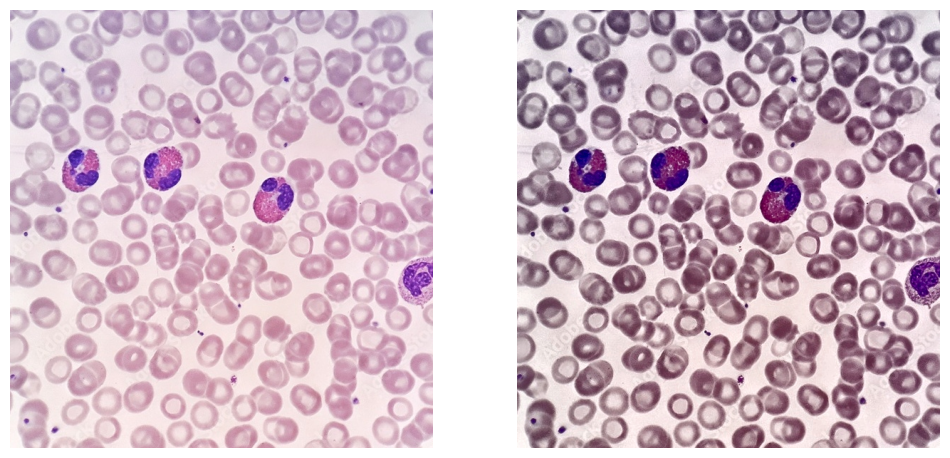


image 1/1 D:\AI-Microscope-Blood-Cell-Detection-System\data\processed\testing_image_cropped_preprocessed.jpg: 640x640 1 Platelets, 172 RBCs, 1 WBC, 395.8ms
Speed: 3.6ms preprocess, 395.8ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\AI-Microscope-Blood-Cell-Detection-System\runs\detect\results\predict_testing_image_with_YOLOv8m_optimized_150_640_16\testing_image_cropped
Generated prediction for conf 0.1 -> testing_image_cropped_conf_10.jpg

image 1/1 D:\AI-Microscope-Blood-Cell-Detection-System\data\processed\testing_image_cropped_preprocessed.jpg: 640x640 133 RBCs, 1 WBC, 397.9ms
Speed: 3.5ms preprocess, 397.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\AI-Microscope-Blood-Cell-Detection-System\runs\detect\results\predict_testing_image_with_YOLOv8m_optimized_150_640_16\testing_image_cropped
Generated prediction for conf 0.2 -> testing_image_cropped_conf_20.jpg

image 1/1 D:\AI-Microscope-Blood-Cell-De

In [50]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

file_name = "testing_image_cropped"

image_path = f"D:\\AI-Microscope-Blood-Cell-Detection-System\\data\\processed\\{file_name}.jpg"
img = cv2.imread(image_path)

if img is None:
    print("Error: Image not found. Please verify the file path.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        
        padding = 0 
        crop_img = img[y+padding:y+h-padding, x+padding:x+w-padding]
        
        lab = cv2.cvtColor(crop_img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        cl = clahe.apply(l)
        limg = cv2.merge((cl, a, b))
        processed_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
        
        preprocessed_path = f"D:\\AI-Microscope-Blood-Cell-Detection-System\\data\\processed\\{file_name}_preprocessed.jpg"
        cv2.imwrite(preprocessed_path, processed_img)
        print(f"Success: Optimized image saved at {preprocessed_path}")
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0].axis('off')
        axes[1].imshow(cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB))
        axes[1].axis('off')
        plt.show()

        model = YOLO(r"D:\AI-Microscope-Blood-Cell-Detection-System\runs\detect\results\yolov8m_optimized\weights\best.pt")
        
        project_path = r"D:\AI-Microscope-Blood-Cell-Detection-System\runs"
        base_name = f"detect/results/predict_testing_image_with_YOLOv8m_optimized_150_640_16/{file_name}"
        output_dir = os.path.join(project_path, base_name)
        
        conf_values = [round(x * 0.1, 1) for x in range(1, 10)]
        
        for conf in conf_values:
            results = model.predict(
                source=preprocessed_path,
                conf=conf,
                save=True,
                project=project_path, 
                name=base_name,                        
                exist_ok=True
            )
            
            original_file = os.path.join(output_dir, f"{file_name}_preprocessed.jpg")
            
            if os.path.exists(original_file):
                new_file_name = f"{file_name}_conf_{int(conf*100)}.jpg"
                new_file_path = os.path.join(output_dir, new_file_name)
                
                if os.path.exists(new_file_path):
                    os.remove(new_file_path)
                    
                os.rename(original_file, new_file_path)
                print(f"Generated prediction for conf {conf} -> {new_file_name}")